# Setup
If you have not run the below code in a separate Julia session, this notebook will not work.
```
using Pkg
Pkg.add("DrWatson")          
Pkg.activate("path/to/temp-tune")
Pkg.instantiate()

cd("path/to/temp-tune")
include(scriptsdir("setup_python.jl"))
```

## activate project

In [14]:
using Pkg
using DrWatson
@quickactivate "temp-tune"
println("current active project = ",Base.active_project())

current active project = /Users/pfields/Git/temp-tune/Project.toml


## setup plotting

In [2]:
include(srcdir("matplotlib_helpers.jl"))
setup_notebook_for_paper()
using_Py(true)

setup_rc_reset()
set_plot_style_for_paper(; venue="revtex")

Plot style set → venue=revtex, font='Arial'
Sizes (pt): label=10.0  tick=8.0  legend=8.0  mathtext.fontset=cm
Python     : /Users/pfields/Git/temp-tune/.conda/bin/python
Matplotlib : 3.10.8 | backend=Agg
 set plot style finished. exiting...



## other packages

In [3]:
using StatsBase, Statistics, LinearAlgebra, Printf, Random
using SpecialFunctions
using Parameters, Flux
using Optim, BenchmarkTools, JLD2, DataFrames, Graphs
using OptimizationOptimJL, Optimization
using Roots, Expectations
using Distributions
using Conda
using Dierckx
using CUDA
using SpinModels

In [4]:
include(srcdir("sweep_nn_ising.jl"))
include(srcdir("nearest_neighbor_ising.jl"))
include(srcdir("samplers.jl"))
include(srcdir("plot_ising_funcs.jl"))

tau_prime_plot (generic function with 1 method)

# Run experiments on 3 by 3 ising model at different T, M and plot results

In [12]:
# params to sweep over -- the ones below are set such that it will run quickly

nreps = 5
true_temps_to_sweep=collect(2.00:0.4:4.4)

mu_vals_to_sweep = [] # mu = log( M / e^H_true ) -- an entropy normalized sample number. 
# leave as empty array if not in use

nsamples_to_sweep = Int.(round.(10 .^collect(range(;start=log10(50), stop=log10(1500), length=10))))

10-element Vector{Int64}:
   50
   73
  106
  155
  227
  331
  483
  704
 1028
 1500

In [13]:
true_temps_to_sweep

7-element Vector{Float64}:
 2.0
 2.4
 2.8
 3.2
 3.6
 4.0
 4.4

In [19]:
tau_sweep_opts_3by3 = TauSweepOptions(
    nreps, mu_vals_to_sweep, 
    true_temps_to_sweep, "constant M", m_by_n=(3,3), 
    nsamples_to_sweep = nsamples_to_sweep );

In [15]:
savedir=datadir("ising_sweeps","constant_M_3by3")
mkpath(savedir)

"/Users/pfields/Git/temp-tune/data/ising_sweeps/constant_M_3by3"

In [16]:
# uncomment to run experiments

run_full_sweeps_exact( tau_sweep_opts_3by3, 
                        savedir, keep_buffer=false )

nsampless = [50.0, 50.0, 50.0, 50.0, 50.0]

rep = 1

TIME ELAPSED = 0 min

 RUNNING SWEEPS FOR N TRAINING SAMPLES = 50.0
getting samples at T=2.0
done!

 fitting model to data taken at T=2.0
iter = 0, -likelihood = 14.578676311638544
   logZ=[10.93460064348355]
   mean energy of train data = [3.644075668154993]
iter = 1000, -likelihood = 1.756169782500331
   logZ=[13.46313679002921]
   mean energy of train data = [-11.70696700752888]
iter = 2000, -likelihood = 1.7213613734815123
   logZ=[15.268201048392665]
   mean energy of train data = [-13.546839674911153]
iter = 2132, -likelihood = 1.718961555536831
relTol of 1.0e-5 reached



 getting samples from fit model on samples taken at T=2.000000 
sweeping fit model tau from 0.2 to 5.0
done!

rep = 2

TIME ELAPSED = 0 min

 RUNNING SWEEPS FOR N TRAINING SAMPLES = 50.0
getting samples at T=2.0
done!

 fitting model to data taken at T=2.0
iter = 0, -likelihood = 17.38302880045297
   logZ=[11.256591024470834]
   mean energy of train data = [6

### make tau sweep plots for one experiment

#### import sweeps
`tau_sweep_opts_3by3` and `savedir` used to load sweeps

In [24]:
df_raw_all_reps = DataFrame() 

append!( df_raw_all_reps, load_from_sweeps( tau_sweep_opts_3by3, savedir ) );

df_raw_all_reps = unique( df_raw_all_reps );
size(df_raw_all_reps)

(70, 13)

In [25]:
df_means_and_splines = DataFrame()

append!( df_means_and_splines, get_means_and_splines_df( tau_sweep_opts_3by3, df_raw_all_reps ) )

df_means_and_splines = unique(df_means_and_splines)
size(df_means_and_splines)

(70, 29)

In [26]:
df_tau_opt_DeltaDkl = DataFrame()

append!( df_tau_opt_DeltaDkl , get_tau_opt_df( tau_sweep_opts_3by3, df_means_and_splines ) )

df_tau_opt_DeltaDkl = unique(df_tau_opt_DeltaDkl)
size(df_tau_opt_DeltaDkl)

(70, 25)

#### break down dkl at tau=1

In [27]:
#which sim to plot

M, T, r = (50.0, 2., 3) # number training data, ground truth temp, replicate index

(50.0, 2.0, 3)

In [28]:
_, J_gt = init_2dNN(tau_sweep_opts_3by3.m_by_n...)
ml_bf = ExactMLBuffer(J_gt);
e_bf = Energy2spinBuffer(ml_bf.all_states, J_gt);

set_plot_style_for_paper(tick_pt=10., legend_pt=10., label_pt=10.)

Plot style set → venue=revtex, font='Arial'
Sizes (pt): label=10.0  tick=10.0  legend=10.0  mathtext.fontset=cm
Python     : /Users/pfields/Git/temp-tune/.conda/bin/python
Matplotlib : 3.10.8 | backend=Agg
 set plot style finished. exiting...



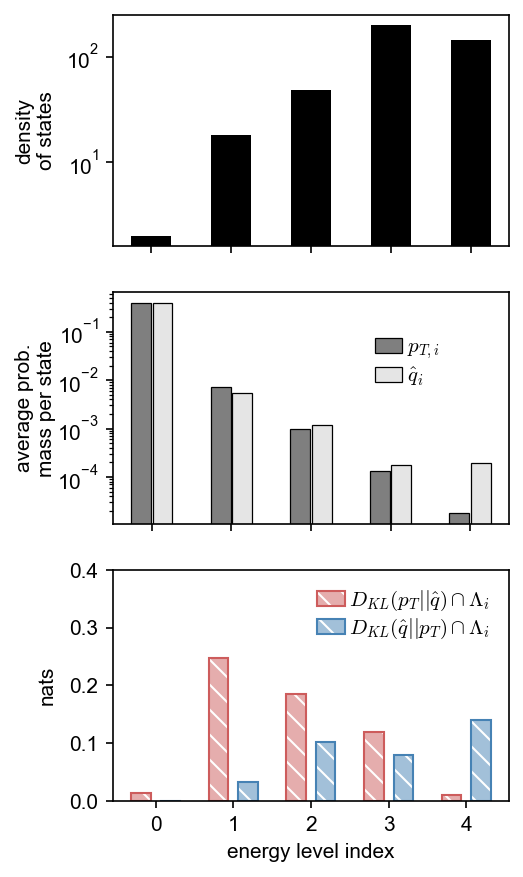

(0.0, 0.4)

In [29]:
fig, ax = subplots(3,1, figsize=set_size_for_paper(1, 2.,), dpi=150)


plot_one_ising_replicate(ax, df_raw_all_reps, M, T, r, J_gt, ml_bf, e_bf;
                            leg3_loc="upper right")

ax[2].yaxis.labelpad = 0.5
ax[1].yaxis.labelpad = 4.5
ax[3].set_ylabel("nats")#, labelpad=6)

ax[1].minorticks_off()

ax[3].set_ylim(0,0.4)

# ffnname="/Users/pfields/Documents/Inkscape/fig3-raw-new_T=$(T)_M=$(M)_r=$(r).svg"

# savefig(ffnname, dpi=600)


#### sweep over sampling temp tau and track dkls

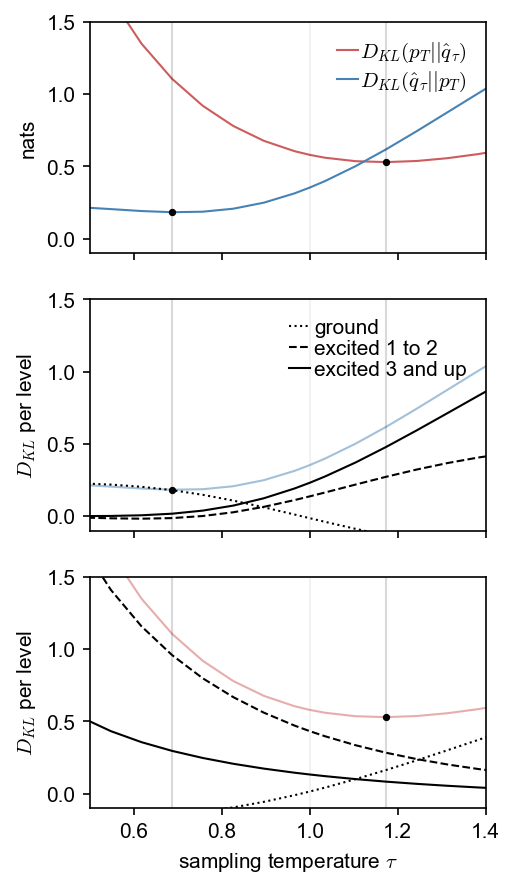

(-0.1, 1.5)

In [30]:
fig, ax = subplots(3,1, figsize=set_size_for_paper(1,2.), dpi=150)


plot_tau_sweep_one_rep(ax, df_raw_all_reps, M, T, r, J_gt, ml_bf, e_bf;
                                    mss=5, lww=1, 
                                    leg3_loc="upper right", 
                                    leg1_loc="upper right",
                                    exct_idx=2)

ax[2].set_xlabel("sampling temperature "*L"\tau")

# ax[1].yaxis.labelpad = 3
# ax[2].yaxis.labelpad = 3
# ax[3].yaxis.labelpad = 3

ax[2].sharey(ax[1])
ax[3].sharey(ax[1])
ax[2].sharex(ax[1])
ax[3].sharex(ax[1])

ax[1].set_ylim(-0.1,1.5)

### opt tau phase plots

In [31]:
true_temps_to_swp, all_Ms_swpt, 
    all_taus, all_taus_prime = get_arrays_for_phase_plot(df_raw_all_reps, df_tau_opt_DeltaDkl);

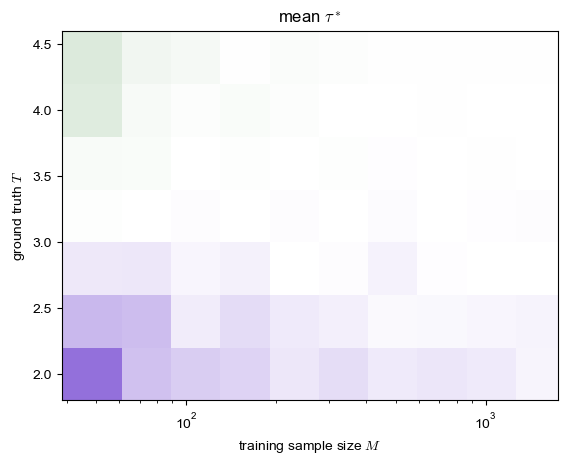

PyObject Text(0.5, 1.0, 'mean $\\tau^*$')

In [33]:
fig, ax =subplots()

tau_star_plots(ax,
            true_temps_to_swp, all_Ms_swpt, 
            all_taus, all_taus_prime ;
            Ts_idxx=1:7,
            Ms_idxx=1:10)

ax.set_title("mean "*L"\tau^*")

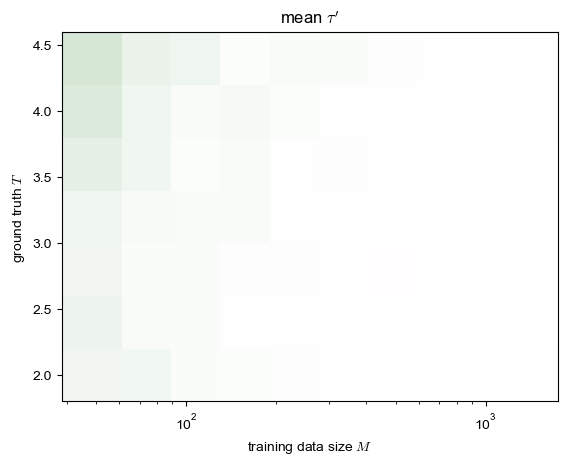

PyObject Text(0.5, 1.0, "mean $\\tau' $")

In [34]:
fig, ax =subplots()

tau_prime_plot(ax,
            true_temps_to_swp, all_Ms_swpt, 
            all_taus, all_taus_prime ;
            Ts_idxx=1:7,
            Ms_idxx=1:10)

ax.set_title("mean "*L"\tau' ")

# reproduce figure 3

### import sims from paper
see instructions in README.md for downloading data

may take 2-3 minutes to import and process data

In [5]:
nreps = 10



nsamples_to_sweep = Int.(round.(10 .^collect(range(;start=log10(50), 
                stop=log10(1500), length=50))))[2:4:end]
true_temps_to_sweep=[ collect(2.00:0.05:3) ; collect(3.2:0.2:5) ]
mu_vals_to_sweep = []
tau_sweep_opts_4by4 = TauSweepOptions(nreps, mu_vals_to_sweep, 
    true_temps_to_sweep, "constant M", m_by_n=(4,4), 
    nsamples_to_sweep = nsamples_to_sweep );



nsamples_to_sweep = Int.(round.( collect( range(; start=2000, stop=10_000, length=4))))
true_temps_to_sweep=[ collect(2.00:0.05:3) ; collect(3.2:0.2:5) ]
tau_sweep_opts_4by4_2 = TauSweepOptions(nreps, mu_vals_to_sweep, 
    true_temps_to_sweep, "constant M", m_by_n=(4,4), 
    nsamples_to_sweep = nsamples_to_sweep );



true_temps_to_sweep_3 = collect(3.05:0.05:3.15)
nsamples_to_sweep = Int.(round.(10 .^collect(range(;start=log10(50), 
                stop=log10(1500), length=50))))[2:4:end]
append!( nsamples_to_sweep,
    Int.(round.( collect( range(; start=2000, stop=10_000, length=4)))))
tau_sweep_opts_4by4_3 = TauSweepOptions(nreps, mu_vals_to_sweep, 
    true_temps_to_sweep_3, "constant M", m_by_n=(4,4), 
    nsamples_to_sweep = nsamples_to_sweep );



savedir  =datadir("ising_sweeps", "constant_M_4by4")
savedir_2=datadir("ising_sweeps", "constant_M_4by4_2")
savedir_3=datadir("ising_sweeps", "constant_M_4by4_3")

"/Users/pfields/Git/temp-tune/data/ising_sweeps/constant_M_4by4_3"

In [6]:
df_raw_all_reps = DataFrame() 

append!( df_raw_all_reps, load_from_sweeps( tau_sweep_opts_4by4, savedir ) )
append!( df_raw_all_reps, load_from_sweeps( tau_sweep_opts_4by4_2, savedir_2 ) )
append!( df_raw_all_reps, load_from_sweeps( tau_sweep_opts_4by4_3, savedir_3 ) )


df_raw_all_reps = unique( df_raw_all_reps );

size(df_raw_all_reps)

(578, 13)

In [7]:
df_means_and_splines = DataFrame()

append!( df_means_and_splines, get_means_and_splines_df( tau_sweep_opts_4by4, df_raw_all_reps ) )
append!( df_means_and_splines, get_means_and_splines_df( tau_sweep_opts_4by4_2, df_raw_all_reps ) )
append!( df_means_and_splines, get_means_and_splines_df( tau_sweep_opts_4by4_3, df_raw_all_reps ) )


df_means_and_splines = unique(df_means_and_splines)

size(df_means_and_splines)

(578, 29)

In [8]:
df_tau_opt_DeltaDkl = DataFrame()

append!( df_tau_opt_DeltaDkl , get_tau_opt_df( tau_sweep_opts_4by4, df_means_and_splines ) )
append!( df_tau_opt_DeltaDkl , get_tau_opt_df( tau_sweep_opts_4by4_2, df_means_and_splines ) )
append!( df_tau_opt_DeltaDkl , get_tau_opt_df( tau_sweep_opts_4by4_3, df_means_and_splines ) )


df_tau_opt_DeltaDkl = unique(df_tau_opt_DeltaDkl)

size(df_tau_opt_DeltaDkl)

(578, 25)

### make plot 

In [9]:
M, T, r = (71.0, 2.05, 3)  # experiment used in paper (replicate index, numeric load order)

(71.0, 2.05, 3)

In [10]:
_, J_gt = init_2dNN(tau_sweep_opts_4by4.m_by_n...)
ml_bf = ExactMLBuffer(J_gt);
e_bf = Energy2spinBuffer(ml_bf.all_states, J_gt);

In [11]:
set_size_for_paper(1, 2.)
set_plot_style_for_paper(venue="revtex", label_pt=8., )
# , legend_pt=6., tick_pt=6., label_pt=8.)

Plot style set → venue=revtex, font='Arial'
Sizes (pt): label=8.0  tick=8.0  legend=8.0  mathtext.fontset=cm
Python     : /Users/pfields/Git/temp-tune/.conda/bin/python
Matplotlib : 3.10.8 | backend=Agg
 set plot style finished. exiting...



In [12]:
true_temps_to_swp, all_Ms_swpt, 
    all_taus, all_taus_prime = get_arrays_for_phase_plot(df_raw_all_reps, df_tau_opt_DeltaDkl);

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


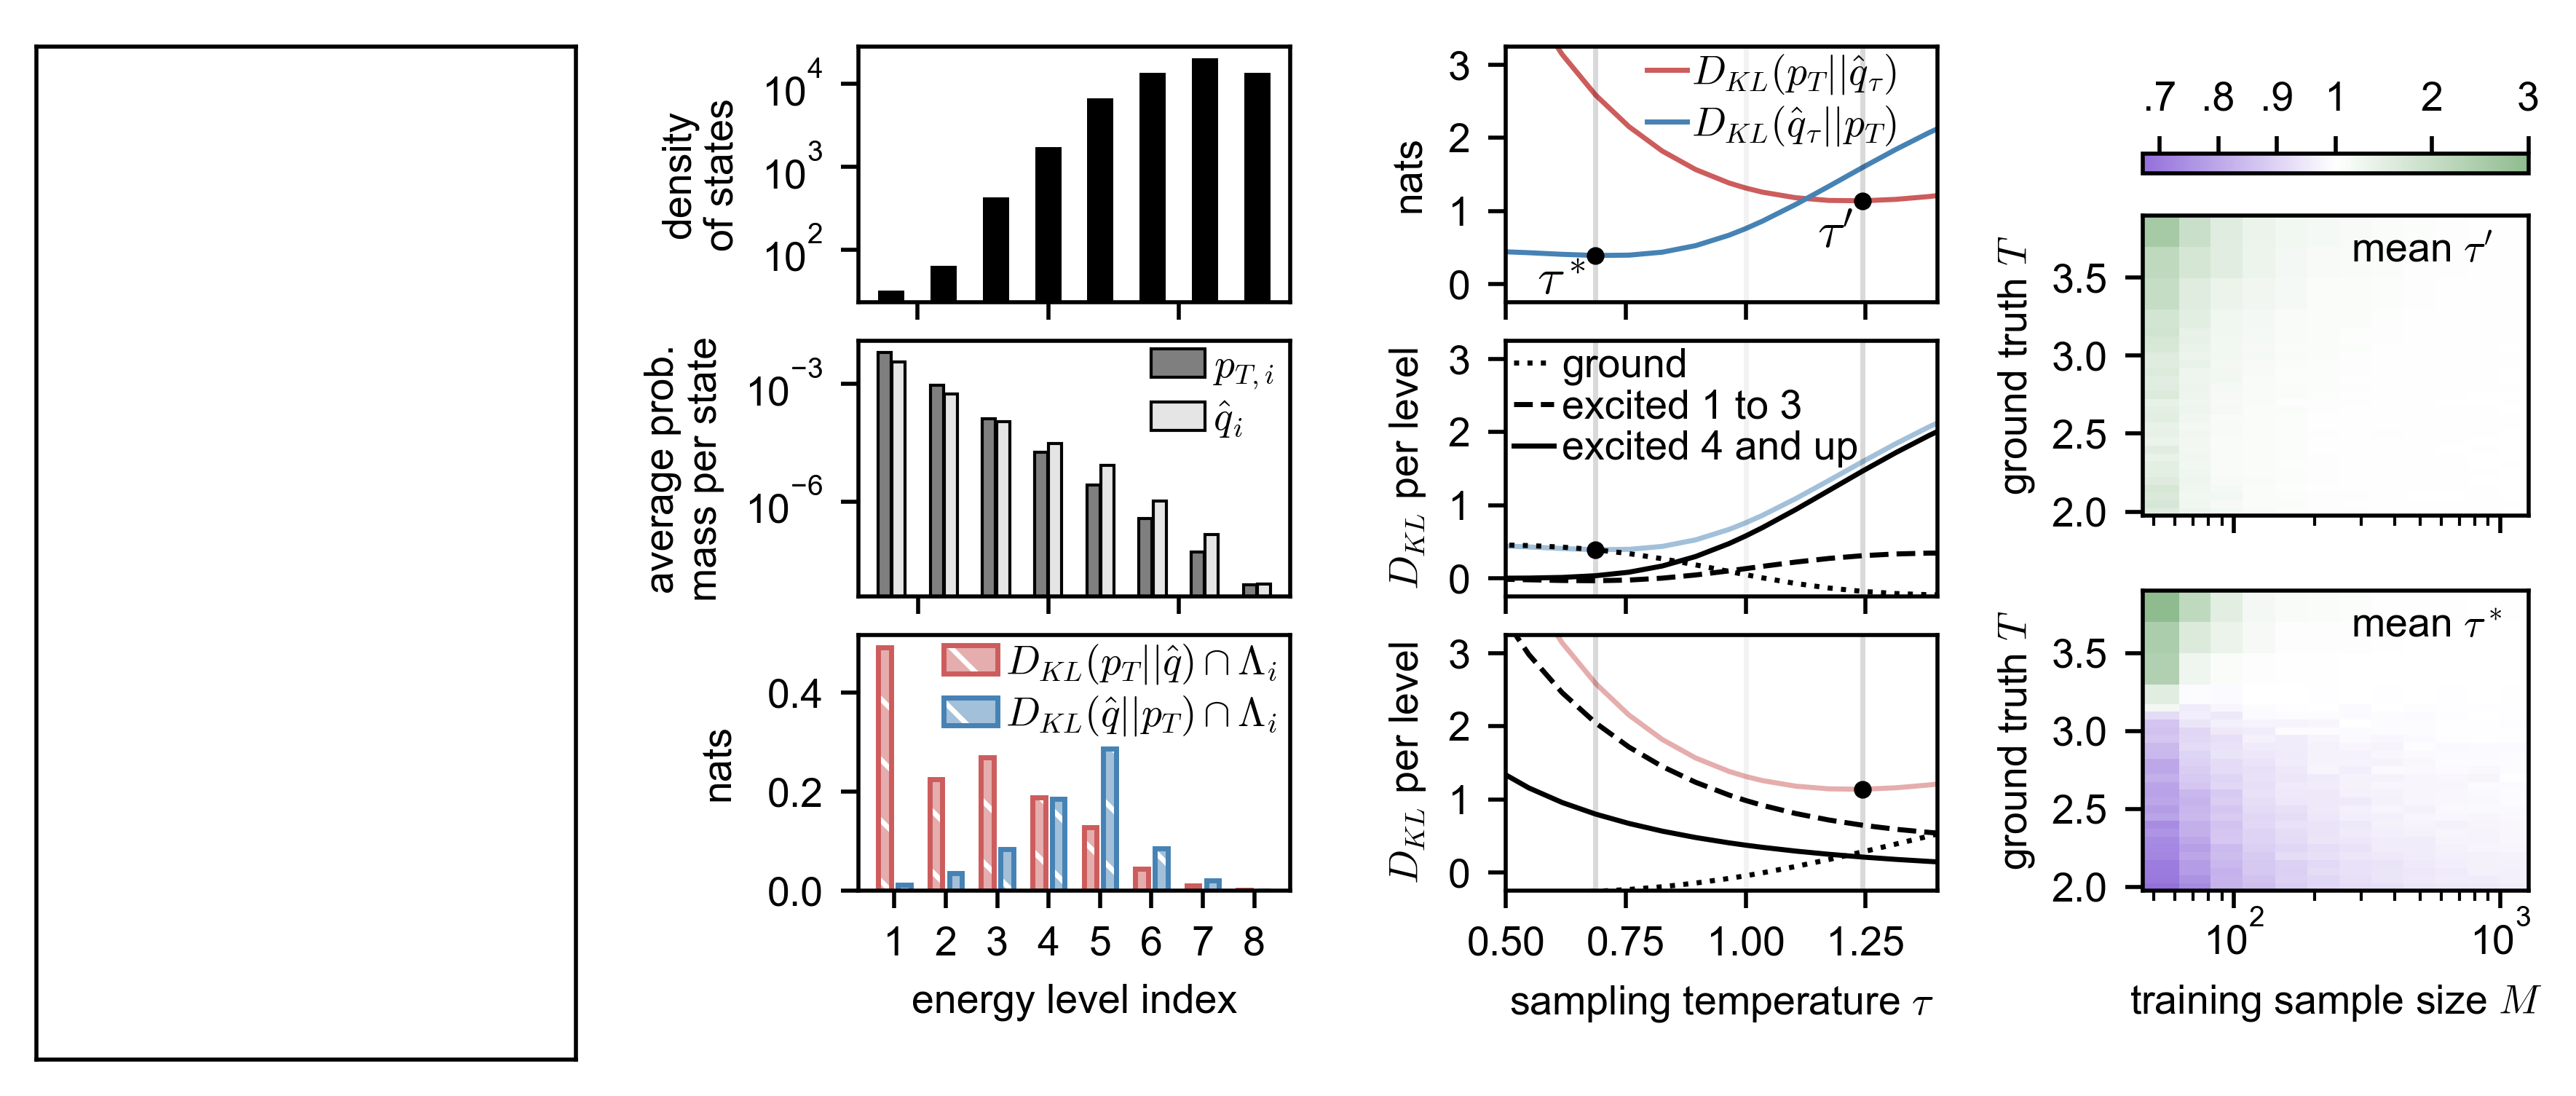

In [13]:
gridspec=matplotlib.gridspec

fig = plt.figure(figsize=set_size_for_paper(2, 4.6/14), dpi=500)

###### INIT FIGURE AND AXES ########################################################################

# Explicit positions as fractions of the figure: left < middle < right
#               left   right  bottom  top
gs_left_up   = fig.add_gridspec(1, 1, left=0.02, right=.23, bottom=-0.2, top=1.)
# gs_left_down = fig.add_gridspec(1, 3, left=0.05, right=0.57, bottom=0.0, top=.35, wspace=0.5)

gs_mid   = fig.add_gridspec(3, 2, left=0.34, right=0.76, bottom=0., top=1., 
    hspace=.15, wspace=0.5)
gs_right = fig.add_gridspec(2, 1, left=0.84, right=.99, bottom=0., top=1., hspace=0.25)


ax_a = fig.add_subplot(gs_left_up[0,0]); 
ax_a.tick_params(labelbottom=false, labelleft=false, left=false, bottom=false)

# ax_a11 = fig.add_subplot(gs_left_up[0]); 
ax_a21 = fig.add_subplot(gs_mid[0,1]); 

ax_a22 = fig.add_subplot(gs_mid[1,1]); #ax_a22.set_title("LEFT 2×2 (2,2)")
ax_a23 = fig.add_subplot(gs_mid[2,1]); 

# Middle block: 3 equal rows
ax_b1 = fig.add_subplot(gs_mid[0, 0])
ax_b2 = fig.add_subplot(gs_mid[1, 0])
ax_b3 = fig.add_subplot(gs_mid[2, 0])

# Right block: 2 equal rows
ax_c2 = fig.add_subplot(gs_right[0, 0]); 
ax_c1 = fig.add_subplot(gs_right[1, 0]); 

#########################################################################################################

ax=[ax_a22, ax_a23, ax_a21, ax_b2, ax_b3, ax_b1 ]

#########################################################################################################

plot_one_ising_replicate(ax[1:3], df_raw_all_reps, M, T, r, J_gt, ml_bf, e_bf;
                            e_lvls_to_show=(2,9))

ax[1].minorticks_off()

#########################################################################################################

plot_tau_sweep_one_rep(ax[4:6], df_raw_all_reps, 
                        M, T, r, J_gt, ml_bf, e_bf;mss=5, lww=1)

ax[4].set_xlim(0.5,1.4)
ax[4].set_ylim(-0.25,3.25)

ax[4].set_yticks(collect(0:3))
ax[4].set_xticks(collect(0.5:0.25:1.25))
ax[5].sharey(ax[4])
ax[6].sharey(ax[4])
ax[5].sharex(ax[4])
ax[6].sharex(ax[4])

ax[4].text( 1.15, 0.5, L"\tau'" , size=10)
ax[4].text( 0.565, -0.135, L"\tau^*" , size=10)

ax[6].set_xlabel("sampling temperature "*L"\tau")

#########################################################################################################

im22=tau_star_plots(ax_c2,
            true_temps_to_swp, all_Ms_swpt, 
            all_taus, all_taus_prime )

im11=tau_prime_plot(ax_c1,
            true_temps_to_swp, all_Ms_swpt, 
            all_taus, all_taus_prime )

ax_c1.set_xlabel(" ")
ax_c2.yaxis.labelpad = 3
ax_c1.yaxis.labelpad = 3
ax_c1.text(275,3.6, "mean "*L"\tau'")
ax_c2.text(275,3.6, "mean "*L"\tau^*")
ax_c1.tick_params(labelbottom=false)
ax_c1.set_xlabel(" ")
ax_c2.tick_params(axis="x", pad=0.5)
ax_c1.set_yticks(collect(2:0.5:3.5))
ax_c2.set_yticks(collect(2:0.5:3.5));

cb=colorbar(im22, ax=[ax_c1,ax_c2],orientation="horizontal", location="top",
        ticks=[0.5, 0.6, 0.7, 0.8, 0.9, 1., 2, 3,4])
cb.set_ticklabels([".5", ".6", ".7", ".8", ".9", "1", "2", "3", "4"]) 

#########################################################################################################

bbox = fig.get_tightbbox(fig.canvas.get_renderer())
# savefig(plotsdir("fig3_reproduced.svg"))

savefig(plotsdir("fig3_reproduced.svg"))

padding_bottom = 0.2 
new_bbox = matplotlib.transforms.Bbox([[bbox.x0, bbox.y0 - padding_bottom], [bbox.x1, bbox.y1]])
savefig(plotsdir("fig3_reproduced_.pdf"), bbox_inches=new_bbox)
